# Plot $c_i$ and $s_i$
## Make a nice plot for the paper

### Add BESIII style

In [1]:
gInterpreter->AddIncludePath("/data/lhcb/users/tat/KKpipi_Analysis_BESIII/include");

In [2]:
gROOT->ProcessLine(".L /data/lhcb/users/tat/KKpipi_Analysis_BESIII/src/Bes3plotstyle.cpp");

In [3]:
SetStyle();
SetPrelimStyle();

### Fit results (just copy them for now)

In [4]:
// Measured values 16 fb^-1
//std::array<double, 4> ci{-0.28, 0.83, 0.83, -0.28};
//std::array<double, 4> si{-0.68, -0.18, 0.27, 0.54};
// Measured values 20 fb^-1
std::array<double, 4> ci{-0.22, 0.79, 0.862, -0.39};
std::array<double, 4> si{-0.47, -0.17, 0.26, 0.52};
// Model values
//std::array<double, 4> ci{-0.362085, 0.808165, 0.835997, -0.380409};
//std::array<double, 4> si{-0.658906, -0.326282, 0.336997, 0.629657};
// Measured values 16 fb^-1
/*std::array<double, 4> ci_err{TMath::Sqrt(0.09*0.09 + 0.01*0.01),
                             TMath::Sqrt(0.04*0.04 + 0.01*0.01),
                             TMath::Sqrt(0.03*0.03 + 0.01*0.01),
                             TMath::Sqrt(0.10*0.10 + 0.01*0.01)};
std::array<double, 4> si_perr{TMath::Sqrt(0.24*0.24 + 0.04*0.04),
                              TMath::Sqrt(0.19*0.19 + 0.03*0.03),
                              TMath::Sqrt(0.17*0.17 + 0.03*0.03),
                              TMath::Sqrt(0.28*0.28 + 0.04*0.04)};*/
// Measured values 20 fb^-1
std::array<double, 4> ci_err{TMath::Sqrt(0.08*0.08 + 0.01*0.01),
                             TMath::Sqrt(0.04*0.04 + 0.01*0.01),
                             TMath::Sqrt(0.029*0.029 + 0.01*0.01),
                             TMath::Sqrt(0.08*0.08 + 0.01*0.01)};
std::array<double, 4> si_perr{TMath::Sqrt(0.22*0.22 + 0.04*0.04),
                              TMath::Sqrt(0.16*0.16 + 0.04*0.04),
                              TMath::Sqrt(0.14*0.14 + 0.02*0.02),
                              TMath::Sqrt(0.24*0.24 + 0.04*0.04)};
// Symmetric uncertainties
std::array<double, 4> si_merr = si_perr;

### Model prediction

In [5]:
std::array<double, 4> ci_Model{-0.362085, 0.808165, 0.835997, -0.380409};
std::array<double, 4> si_Model{-0.658906, -0.326282, 0.336997, 0.629657};

### Points for circle

In [6]:
const std::size_t Points = 101;
std::vector<double> circle_x(Points), circle_y(Points);
for(std::size_t i = 0; i < 101; i++) {
    circle_x[i] = TMath::Cos(2.0*TMath::Pi()*i/100.0);
    circle_y[i] = TMath::Sin(2.0*TMath::Pi()*i/100.0);
}

### Make plot

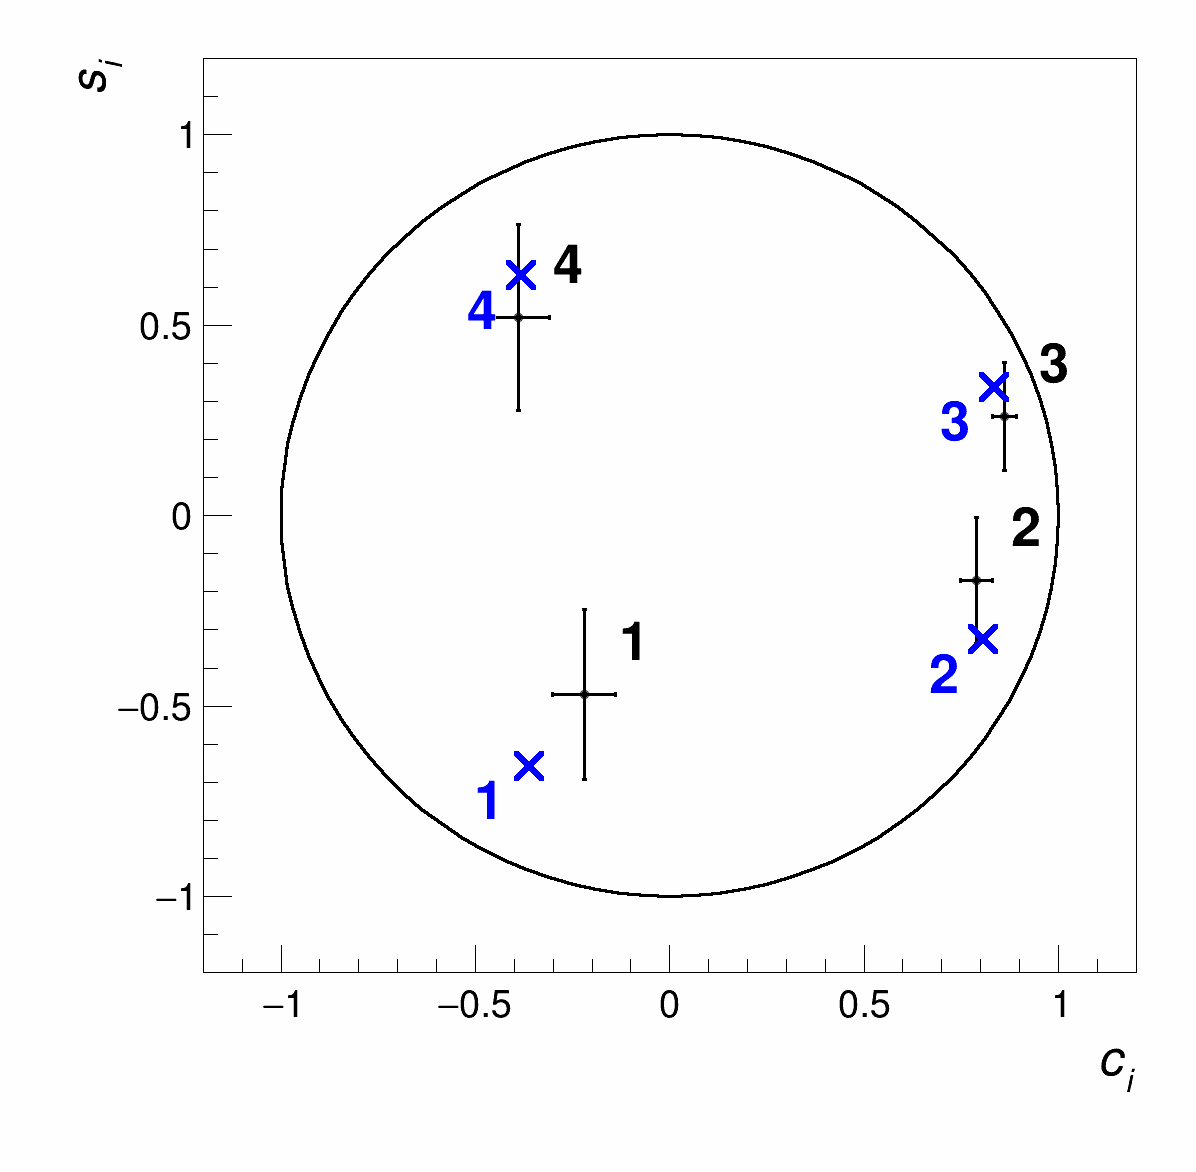

Info in <TCanvas::Print>: pdf file cisi_FitResults_Model.pdf has been created


In [7]:
TGraphAsymmErrors Graph(ci.size(),
                        ci.data(), si.data(),
                        ci_err.data(), ci_err.data(),
                        si_merr.data(), si_perr.data());
Graph.SetTitle(";#it{c_{i}};#it{s_{i}}");
TCanvas c("c", "", 1200, 1200);
Graph.GetYaxis()->SetTitleOffset(1.2);
Graph.SetMarkerStyle(20);
Graph.SetLineWidth(3);
Graph.GetXaxis()->SetLimits(-1.2, 1.2);
Graph.GetYaxis()->SetRangeUser(-1.2, 1.2);
Graph.GetXaxis()->SetNdivisions(505);
Graph.GetYaxis()->SetNdivisions(505);
Graph.GetXaxis()->SetLabelSize(0.035);
Graph.GetYaxis()->SetLabelSize(0.035);
Graph.GetXaxis()->SetTitleSize(0.045);
Graph.GetYaxis()->SetTitleSize(0.045);
Graph.Draw("APE");
TGraph Circle(Points, circle_x.data(), circle_y.data());
Circle.SetLineWidth(3);
Circle.Draw("L SAME");
TGraph ModelPoints(ci_Model.size(), ci_Model.data(), si_Model.data());
ModelPoints.SetMarkerStyle(106);
ModelPoints.SetMarkerSize(5);
ModelPoints.SetMarkerColor(kBlue);
ModelPoints.Draw("P SAME");
std::vector<TLatex> PointLabels, PointLabels_data;
for(std::size_t Bin = 1; Bin <= ci.size(); Bin++) {
    PointLabels.push_back(TLatex(ci_Model[Bin - 1] - 0.14,
                                 si_Model[Bin - 1] - 0.14,
                                 ("#color[4]{" + std::to_string(Bin) + "}").c_str()));
    PointLabels.back().DrawClone("SAME");
    PointLabels_data.push_back(TLatex(ci[Bin - 1] + 0.09,
                                      si[Bin - 1] + 0.09,
                                      std::to_string(Bin).c_str()));
    PointLabels_data.back().DrawClone("SAME");
}
c.Draw();
c.SaveAs("cisi_FitResults_Model.pdf");

In [8]:
c.Close();